# Comparación de observables: RBM 3 capas vs Red de 5 capas vs TFIM exacto

Este notebook abre los ficheros generados por los otros dos:

- `Datos/obvles_3_capas.txt` — observables del barrido VMC con la RBM de 3 capas
  (la red aprende $|\psi_0\rangle$ y se calcula $\langle |m| \rangle$ y $\chi$
  por muestreo Metropolis).
- `Datos/obvles_5_capas.txt` — observables del modelo de regresión + clasificación
  de 5 capas (la red predice $g$ y reconstruimos $\langle |m| \rangle$ y $\chi$
  diagonalizando con el $g_{\text{pred}}$).

y los compara contra el valor exacto en función de $g = h/J$, prestando especial
atención a la zona crítica $g \approx 1$, donde:

- la RBM de 3 capas tiene problemas porque $\chi$ es la diferencia de dos
  cantidades casi iguales y su error está amplificado;
- la red de 5 capas pasa por la diagonalización exacta del $g$ predicho, así que
  el error está controlado únicamente por la precisión en $g$.

## 1. Lectura de los ficheros


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "Datos"

def load_txt(path):
    """Lee un fichero generado por los notebooks (las líneas que empiezan
    por '#' son cabecera). Devuelve un array (n_filas, n_cols)."""
    return np.loadtxt(path, comments="#")


path_3 = os.path.join(DATA_DIR, "obvles_3_capas_NQS_bien.txt")
path_5 = os.path.join(DATA_DIR, "obvles_5_capas_hamiltonianlearning.txt")
path_7 = os.path.join(DATA_DIR, "obvles_7_capas_NQS_init.txt")

data_3 = load_txt(path_3)
data_5 = load_txt(path_5)
data_7 = load_txt(path_7)

print(f"3 capas: {data_3.shape}  ({path_3})")
print(f"5 capas: {data_5.shape}  ({path_5})")
print(f"7 capas: {data_7.shape}  ({path_7})")


3 capas: (15, 10)  (Datos\obvles_3_capas_NQS_bien.txt)
5 capas: (225, 10)  (Datos\obvles_5_capas_hamiltonianlearning.txt)
7 capas: (15, 10)  (Datos\obvles_7_capas_NQS_init.txt)


## 2. Desempaquetado

**Columnas del fichero de 3 capas** (15 valores de $g$ del barrido):

`g  h  E_RBM  E_err  m_RBM  m_err  chi_RBM  chi_err  E_exact  m_exact  chi_exact`

**Columnas del fichero de 5 capas** (muestras del test set, $g$ aleatorio):

`g_real  g_pred  E_real(E0/N)  E_pred(E0/N)  m_exact  m_pred  chi_exact  chi_pred  fase_real  fase_pred`


In [4]:
g3       = data_3[:, 0]
m3_rbm   = data_3[:, 3]
m3_err   = data_3[:, 4]
chi3_rbm = data_3[:, 5]
chi3_err = data_3[:, 6]
m3_ex    = data_3[:, 8]
chi3_ex  = data_3[:, 9]

g7 = data_7[:, 0]
m7_rbm = data_7[:, 3]
m7_err = data_7[:, 4]
chi7_rbm = data_7[:, 5]
chi7_err = data_7[:, 6]
m7_ex = data_7[:, 8]
chi7_ex = data_7[:, 9]

g5_real = data_5[:, 0]
g5_pred = data_5[:, 1]
m5_ex   = data_5[:, 4]
m5_pred = data_5[:, 5]
chi5_ex = data_5[:, 6]
chi5_pred = data_5[:, 7]

order_5 = np.argsort(g5_real)
g5_real_o   = g5_real[order_5]
g5_pred_o   = g5_pred[order_5]
m5_ex_o     = m5_ex[order_5]
m5_pred_o   = m5_pred[order_5]
chi5_ex_o   = chi5_ex[order_5]
chi5_pred_o = chi5_pred[order_5]


# Curva exacta densa uniendo ambos ficheros, ordenada por g
g_dense_ex   = np.concatenate([g3, g5_real_o])
m_dense_ex   = np.concatenate([m3_ex, m5_ex_o])
chi_dense_ex = np.concatenate([chi3_ex, chi5_ex_o])
ord_dense = np.argsort(g_dense_ex)
g_dense_ex   = g_dense_ex[ord_dense]
m_dense_ex   = m_dense_ex[ord_dense]
chi_dense_ex = chi_dense_ex[ord_dense]

print(f"3 capas: {len(g3)} puntos en g = {g3.min():.2f}..{g3.max():.2f}")
print(f"5 capas: {len(g5_real)} muestras en g = {g5_real.min():.2f}..{g5_real.max():.2f}")

3 capas: 15 puntos en g = 0.10..2.00
5 capas: 225 muestras en g = 0.13..1.99


## 3. Comparación de magnetización


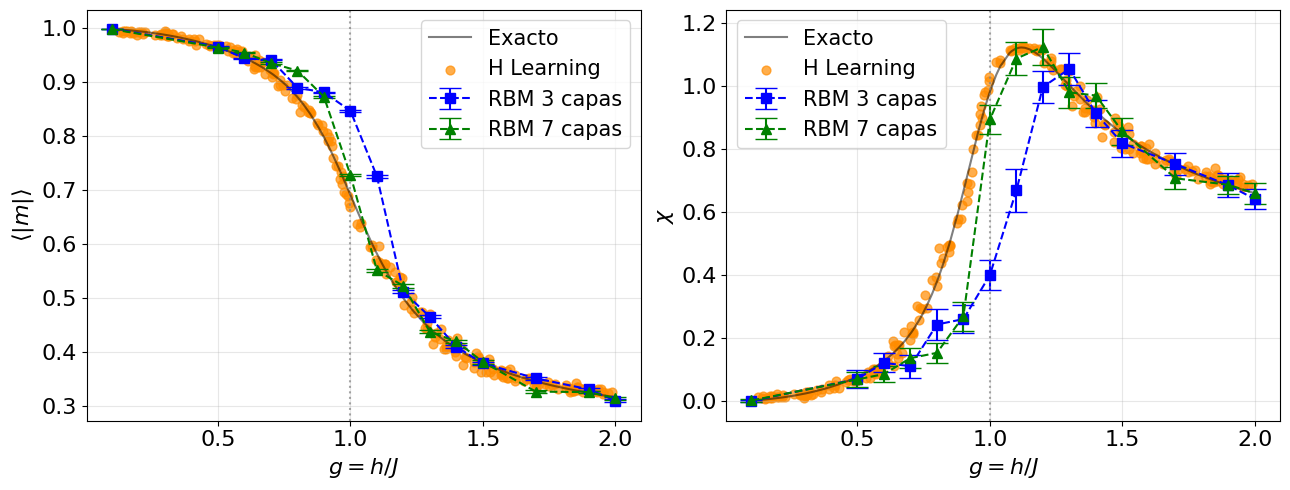

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(g_dense_ex, m_dense_ex, "k-", lw=1.5, alpha=0.5, label="Exacto")
ax.errorbar(g3, m3_rbm, yerr=m3_err, fmt="bs--", capsize=8, markersize=7,
            label="RBM 3 capas")

ax.errorbar(g7, m7_rbm, yerr=m7_err, fmt="g^--", capsize=8, markersize=7,
            label="RBM 7 capas")

ax.scatter(g5_real_o, m5_pred_o, c="darkorange", marker="o", s=40, alpha=0.7,
           label=r"H Learning")
ax.axvline(1.0, color="gray", ls=":", alpha=0.7)
ax.set_xlabel(r"$g = h/J$",fontsize=16)
ax.set_ylabel(r"$\langle |m| \rangle$",fontsize=16)
ax.legend(fontsize=15); ax.grid(alpha=0.3)
ax.tick_params(axis='both', labelsize=16)
ax.set_title("(a)", fontsize=16)

ax = axes[1]
ax.plot(g_dense_ex, chi_dense_ex, "k-", lw=1.5, alpha=0.5, label="Exacto")
ax.errorbar(g3, chi3_rbm, yerr=chi3_err, fmt="bs--", capsize=8, markersize=7,
            label="RBM 3 capas")
ax.errorbar(g7, chi7_rbm, yerr=chi7_err, fmt="g^--", capsize=8, markersize=7,
            label="RBM 7 capas")
ax.scatter(g5_real_o, chi5_pred_o, c="darkorange", marker="o", s=40, alpha=0.7,
           label=r"H Learning")
ax.axvline(1.0, color="gray", ls=":", alpha=0.7)
ax.set_xlabel(r"$g = h/J$",fontsize=16)
ax.set_ylabel(r"$\chi$",fontsize=16)
ax.legend(fontsize=15); ax.grid(alpha=0.3)
ax.tick_params(axis='both', labelsize=16)
ax.set_title("(b)", fontsize=16)
plt.tight_layout()
plt.savefig("comparacion_hamiltonian_learning.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Comparación de susceptibilidad

El parámetro de mayor interés cerca del punto crítico: aquí es donde se ve
mejor la diferencia entre los dos enfoques.


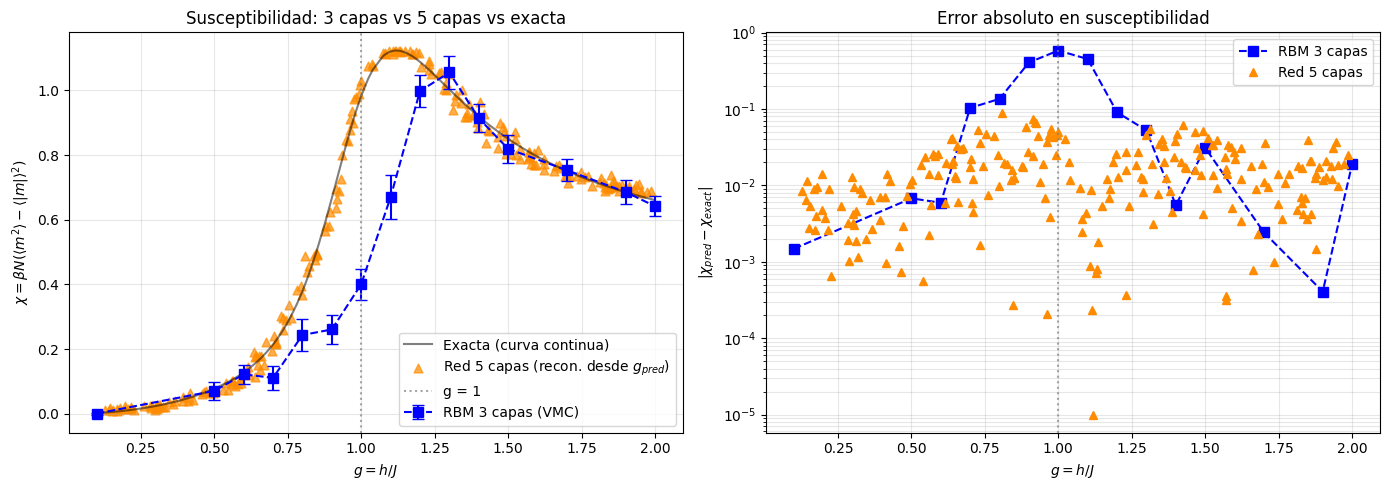

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(g_dense_ex, chi_dense_ex, "k-", lw=1.5, alpha=0.5, label="Exacta (curva continua)")
ax.errorbar(g3, chi3_rbm, yerr=chi3_err, fmt="bs--", capsize=4, markersize=7,
            label="RBM 3 capas (VMC)")
ax.scatter(g5_real_o, chi5_pred_o, c="darkorange", marker="^", s=40, alpha=0.7,
           label=r"Red 5 capas (recon. desde $g_{pred}$)")
ax.axvline(1.0, color="gray", ls=":", alpha=0.7, label="g = 1")
ax.set_xlabel(r"$g = h/J$")
ax.set_ylabel(r"$\chi = \beta N (\langle m^2 \rangle - \langle |m| \rangle^2)$")
ax.set_title("Susceptibilidad: 3 capas vs 5 capas vs exacta")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
err3   = np.abs(chi3_rbm - chi3_ex)
err5   = np.abs(chi5_pred_o - chi5_ex_o)
ax.semilogy(g3, np.maximum(err3, 1e-6), "bs--", markersize=7, label="RBM 3 capas")
ax.semilogy(g5_real_o, np.maximum(err5, 1e-6), "^", color="darkorange",
            markersize=6, label="Red 5 capas")
ax.axvline(1.0, color="gray", ls=":", alpha=0.7)
ax.set_xlabel(r"$g = h/J$")
ax.set_ylabel(r"$|\chi_{pred} - \chi_{exact}|$")
ax.set_title("Error absoluto en susceptibilidad")
ax.legend(); ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("comparacion_susceptibilidad.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Zoom a la zona crítica

Aquí se ve quién sufre más al cruzar la transición.


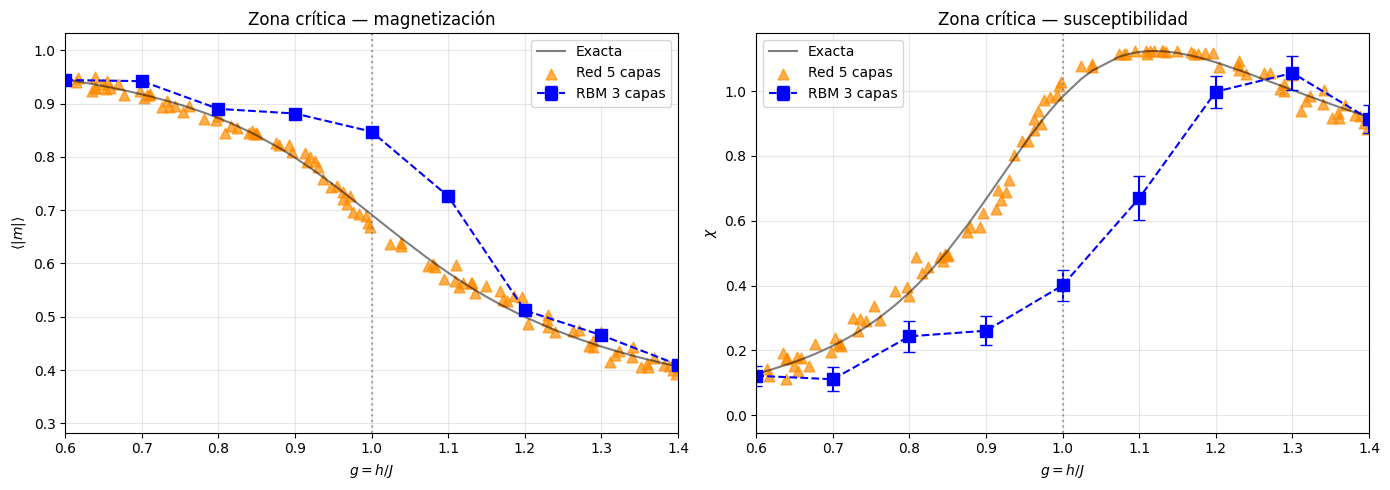

In [ ]:
mask_3 = np.abs(g3 - 1.0) <= 0.4
mask_5 = np.abs(g5_real_o - 1.0) <= 0.4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(g_dense_ex, m_dense_ex, "k-", lw=1.5, alpha=0.5, label="Exacta")
ax.errorbar(g3[mask_3], m3_rbm[mask_3], yerr=m3_err[mask_3], fmt="bs--",
            capsize=4, markersize=8, label="RBM 3 capas")
ax.scatter(g5_real_o[mask_5], m5_pred_o[mask_5], c="darkorange",
           marker="^", s=60, alpha=0.7, label="Red 5 capas")
ax.axvline(1.0, color="gray", ls=":", alpha=0.7)
ax.set_xlim(0.6, 1.4)
ax.set_xlabel(r"$g = h/J$"); ax.set_ylabel(r"$\langle |m| \rangle$")
ax.set_title("Zona crítica — magnetización")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(g_dense_ex, chi_dense_ex, "k-", lw=1.5, alpha=0.5, label="Exacta")
ax.errorbar(g3[mask_3], chi3_rbm[mask_3], yerr=chi3_err[mask_3], fmt="bs--",
            capsize=4, markersize=8, label="RBM 3 capas")
ax.scatter(g5_real_o[mask_5], chi5_pred_o[mask_5], c="darkorange",
           marker="^", s=60, alpha=0.7, label="Red 5 capas")
ax.axvline(1.0, color="gray", ls=":", alpha=0.7)
ax.set_xlim(0.6, 1.4)
ax.set_xlabel(r"$g = h/J$"); ax.set_ylabel(r"$\chi$")
ax.set_title("Zona crítica — susceptibilidad")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparacion_zona_critica.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Tabla resumen — errores medios

Calculamos errores absolutos medios globales y en la región crítica $|g - 1| \leq 0.15$.


In [ ]:
def stats(diff, mask=None):
    d = diff if mask is None else diff[mask]
    return d.mean(), d.std(), d.max()

err_m3   = np.abs(m3_rbm - m3_ex)
err_chi3 = np.abs(chi3_rbm - chi3_ex)
err_m5   = np.abs(m5_pred - m5_ex)
err_chi5 = np.abs(chi5_pred - chi5_ex)

mask_crit_3 = np.abs(g3 - 1.0) <= 0.15
mask_crit_5 = np.abs(g5_real - 1.0) <= 0.15

print("=" * 75)
print("Errores absolutos medios (mean ± std, [max])")
print("=" * 75)
print(f"{'Modelo':<25} {'<|m|>':<25} {'chi':<25}")
print("-" * 75)

for label, em, ec in [
    ("3 capas (global)", err_m3, err_chi3),
    ("5 capas (global)", err_m5, err_chi5),
]:
    mm, sm, xm = stats(em); mc, sc, xc = stats(ec)
    print(f"{label:<25} {mm:.4f} ± {sm:.4f} [{xm:.4f}]   "
          f"{mc:.4f} ± {sc:.4f} [{xc:.4f}]")

print()
print(f"--- Región crítica (|g - 1| <= 0.15) ---")
for label, em, ec, mk in [
    ("3 capas (crítica)", err_m3, err_chi3, mask_crit_3),
    ("5 capas (crítica)", err_m5, err_chi5, mask_crit_5),
]:
    if mk.sum() == 0:
        print(f"{label:<25} (sin muestras en esta zona)")
        continue
    mm, sm, xm = stats(em, mk); mc, sc, xc = stats(ec, mk)
    print(f"{label:<25} {mm:.4f} ± {sm:.4f} [{xm:.4f}]   "
          f"{mc:.4f} ± {sc:.4f} [{xc:.4f}]   "
          f"(n={mk.sum()})")
print("=" * 75)


Errores absolutos medios (mean ± std, [max])
Modelo                    <|m|>                     chi                      
---------------------------------------------------------------------------
3 capas (global)          0.0323 ± 0.0502 [0.1559]   0.1262 ± 0.1843 [0.5823]
5 capas (global)          0.0073 ± 0.0066 [0.0339]   0.0173 ± 0.0160 [0.0898]

--- Región crítica (|g - 1| <= 0.15) ---
3 capas (crítica)         0.1275 ± 0.0319 [0.1559]   0.4796 ± 0.0748 [0.5823]   (n=3)
5 capas (crítica)         0.0120 ± 0.0074 [0.0268]   0.0236 ± 0.0224 [0.0747]   (n=36)


## 7. Lectura física

- **RBM de 3 capas (VMC):** aprende el estado fundamental directamente como NQS y
  los observables salen del muestreo. Cerca del punto crítico la $\chi$ está
  dominada por la varianza de $m$ y es donde más se nota la dificultad del VMC.

- **Red de 5 capas (regresión + clasificación):** sólo aprende a inferir $g$ y la
  fase a partir del estado ruidoso. Los observables se reconstruyen por
  diagonalización exacta del Hamiltoniano con el $g_{\text{pred}}$. El error en
  los observables está entonces controlado por la precisión en $g$ y por la
  pendiente local $\partial \langle O \rangle / \partial g$, que es máxima en $g \approx 1$.

Si el modelo de 5 capas predice $g$ bien (algo razonable si el ruido es moderado),
el acuerdo en $\langle |m| \rangle$ y $\chi$ es típicamente mejor que el del VMC
en la región crítica, porque no se hereda la varianza de muestreo.
